Repo root: C:\Users\matte\PyCharmMiscProject\aero-surrogate
Loaded model 'dropout' on device: cpu
Using alpha sweep: -4.0 .. 20.0 deg (step 0.5 deg), N=49
Found 158 unique training NACAs.
Saving plots to: C:\Users\matte\PyCharmMiscProject\aero-surrogate\reports\evaluation_plots

--- Predicting known NACA polar ---


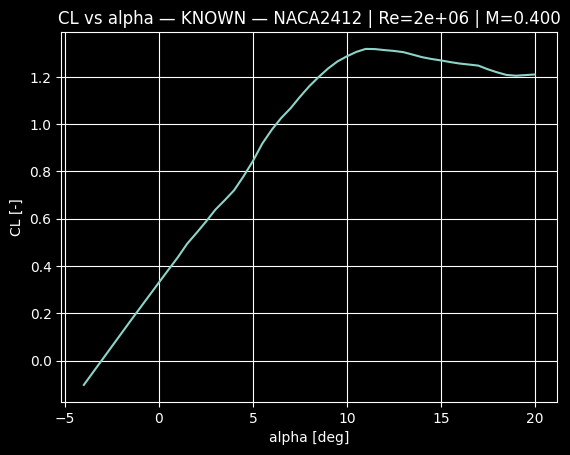

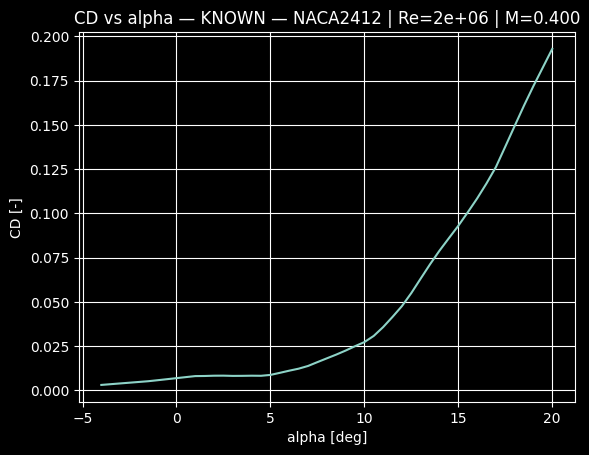

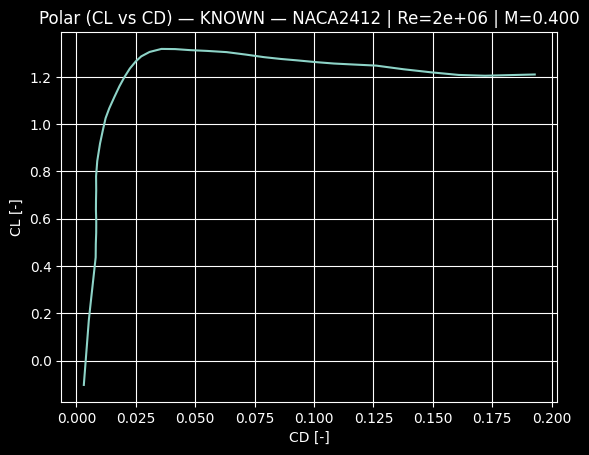


--- Predicting unseen NACA polar ---


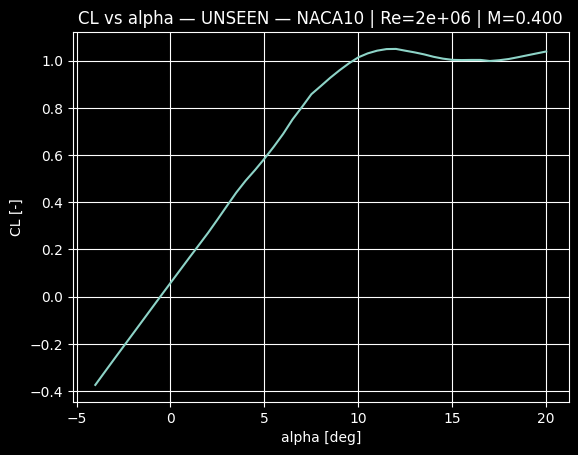

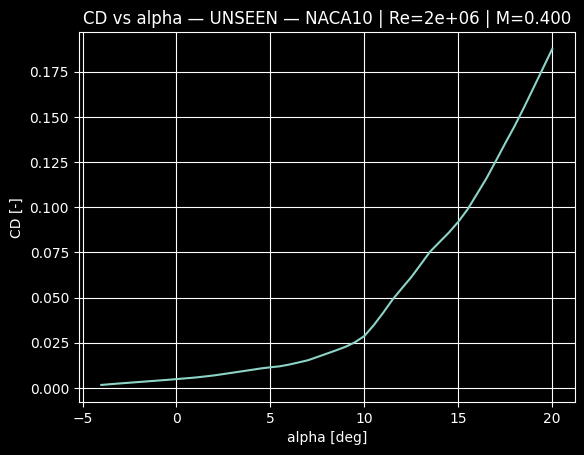

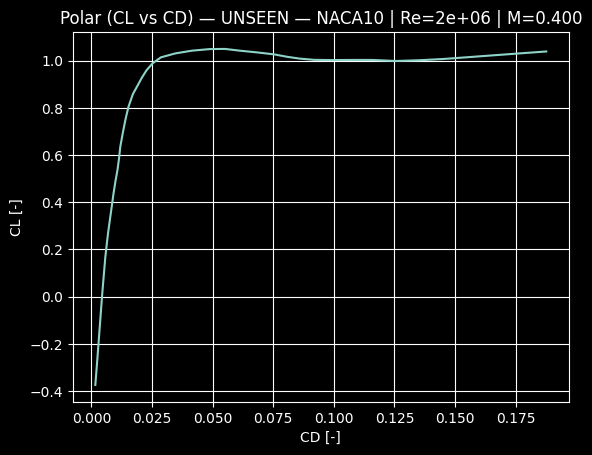

Elapsed evaluation time: 0 min 1.04 s

Saved:
  C:\Users\matte\PyCharmMiscProject\aero-surrogate\reports\evaluation_plots\pred_polar_known_NACA2412_Re2e+06_M0.400.csv
  C:\Users\matte\PyCharmMiscProject\aero-surrogate\reports\evaluation_plots\pred_polar_unseen_NACA10_Re2e+06_M0.400.csv


In [1]:
from __future__ import annotations
import time

import os
from pathlib import Path
from typing import Tuple, Dict, Any, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# --------------
# Generic model
# --------------
class GenericModel(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, hidden_layers, activation="relu", dropout=0.0):
        super().__init__()

        layers = []
        in_dim = input_dim

        act_map = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "sigmoid": nn.Sigmoid
        }
        if activation not in act_map:
            raise ValueError(f"Unknown activation: {activation}. Expected one of {list(act_map.keys())}")

        act = act_map[activation]

        for h in hidden_layers:
            layers.append(nn.Linear(in_dim, h))
            layers.append(act())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(float(dropout)))
            in_dim = h

        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# -----------------------------
# Paths (repo-root relative)
# -----------------------------
def get_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data").exists():
        return cwd
    if (cwd.parent / "data").exists():
        return cwd.parent
    return cwd.parents[0]


# -----------------------------
# Load training normalization + model config + weights
# -----------------------------
def load_artifacts(root: Path, model_name: str, use_best: bool = True, device: Optional[str] = None):
    data_path = root / "data" / "processed"
    npz_path = data_path / "data_for_training.npz"
    info_path = data_path / "model_info.npy"
    weights_dir = data_path / "trained_models"

    if not npz_path.exists():
        raise FileNotFoundError(f"Missing: {npz_path}")
    if not info_path.exists():
        raise FileNotFoundError(f"Missing: {info_path}")
    if not weights_dir.exists():
        raise FileNotFoundError(f"Missing: {weights_dir}")

    data = np.load(npz_path)

    X_mean = torch.tensor(data["X_mean"], dtype=torch.float32)
    X_std  = torch.tensor(data["X_std"], dtype=torch.float32)
    Y_mean = torch.tensor(data["Y_mean"], dtype=torch.float32)
    Y_std  = torch.tensor(data["Y_std"], dtype=torch.float32)

    model_info: Dict[str, Any] = np.load(info_path, allow_pickle=True).item()
    if model_name not in model_info:
        raise KeyError(f"Model '{model_name}' not found in model_info. Available: {list(model_info.keys())}")

    cfg = model_info[model_name]
    model = GenericModel(
        input_dim=int(cfg["input_dim"]),
        output_dim=int(cfg["output_dim"]),
        hidden_layers=list(cfg["layers"]),
        activation=str(cfg["activation"]),
        dropout=float(cfg["dropout"]),
    )

    weight_file = f"{model_name}_best.pth" if use_best else f"{model_name}_weights.pth"
    weight_path = weights_dir / weight_file
    if not weight_path.exists():
        raise FileNotFoundError(f"Missing weights: {weight_path}")

    # device
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    dev = torch.device(device)

    model.load_state_dict(torch.load(weight_path, map_location=dev))
    model.to(dev).eval()

    # move norm stats to device as well
    X_mean, X_std, Y_mean, Y_std = X_mean.to(dev), X_std.to(dev), Y_mean.to(dev), Y_std.to(dev)

    return model, (X_mean, X_std, Y_mean, Y_std), dev


# -----------------------------
# Alpha sweep
# -----------------------------
def default_alpha_sweep() -> np.ndarray:
    alpha_start, alpha_end, alpha_step = -4.0, 20.0, 0.5
    return np.round(np.arange(alpha_start, alpha_end + 1e-9, alpha_step), 6)


# -----------------------------
# Predict a polar
# -----------------------------
@torch.no_grad()
def predict_polar(
    model: nn.Module,
    norms: Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor],
    device: torch.device,
    naca: int,
    Re: float,
    Mach: float,
    alphas_deg: np.ndarray,
) -> pd.DataFrame:
    X_mean, X_std, Y_mean, Y_std = norms

    # Build raw input matrix: [naca, Re, Mach, alpha_deg]
    n = len(alphas_deg)
    X_raw = np.column_stack([
        np.full(n, float(naca), dtype=np.float32),
        np.full(n, float(Re), dtype=np.float32),
        np.full(n, float(Mach), dtype=np.float32),
        alphas_deg.astype(np.float32)
    ])

    X = torch.tensor(X_raw, dtype=torch.float32, device=device)
    Xn = (X - X_mean) / X_std

    Yn_pred = model(Xn)                 # normalized prediction
    Y_pred = Yn_pred * Y_std + Y_mean   # de-normalize back to CL, CD

    Y_pred_np = Y_pred.detach().cpu().numpy()

    df = pd.DataFrame({
        "alpha_deg": alphas_deg,
        "CL": Y_pred_np[:, 0],
        "CD": Y_pred_np[:, 1],
        "naca": naca,
        "Re": Re,
        "Mach": Mach,
    })
    return df


# -----------------------------
# Plotting
# -----------------------------
def plot_polar_set(df: pd.DataFrame, title_prefix: str = "", save_dir: Optional[Path] = None):
    naca = int(df["naca"].iloc[0])
    Re = float(df["Re"].iloc[0])
    Mach = float(df["Mach"].iloc[0])

    suffix = f"NACA{naca} | Re={Re:.3g} | M={Mach:.3f}"
    if title_prefix:
        suffix = f"{title_prefix} — {suffix}"

    # 1) CL vs alpha
    plt.figure()
    plt.plot(df["alpha_deg"], df["CL"])
    plt.xlabel("alpha [deg]")
    plt.ylabel("CL [-]")
    plt.title(f"CL vs alpha — {suffix}")
    plt.grid(True)

    if save_dir:
        save_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_dir / f"CL_vs_alpha_NACA{naca}_Re{Re:.3g}_M{Mach:.3f}.png", dpi=160, bbox_inches="tight")
    plt.show()

    # 2) CD vs alpha
    plt.figure()
    plt.plot(df["alpha_deg"], df["CD"])
    plt.xlabel("alpha [deg]")
    plt.ylabel("CD [-]")
    plt.title(f"CD vs alpha — {suffix}")
    plt.grid(True)

    if save_dir:
        plt.savefig(save_dir / f"CD_vs_alpha_NACA{naca}_Re{Re:.3g}_M{Mach:.3f}.png", dpi=160, bbox_inches="tight")
    plt.show()

    # 3) CL vs CD (polar)
    plt.figure()
    plt.plot(df["CD"], df["CL"])
    plt.xlabel("CD [-]")
    plt.ylabel("CL [-]")
    plt.title(f"Polar (CL vs CD) — {suffix}")
    plt.grid(True)

    if save_dir:
        plt.savefig(save_dir / f"Polar_CL_vs_CD_NACA{naca}_Re{Re:.3g}_M{Mach:.3f}.png", dpi=160, bbox_inches="tight")
    plt.show()


# -----------------------------
# Pick a known/unseen NACA from your dataset
# -----------------------------
def get_training_nacas(root: Path) -> np.ndarray:
    csv_path = root / "data" / "processed" / "xfoil_dataset_rows.csv"
    if not csv_path.exists():
        return np.array([], dtype=int)

    df = pd.read_csv(csv_path)
    if "naca" not in df.columns:
        return np.array([], dtype=int)

    df["naca"] = pd.to_numeric(df["naca"], errors="coerce")
    df = df.dropna(subset=["naca"])
    nacas = np.unique(df["naca"].astype(int).values)
    return nacas


# -----------------------------
# Main (interactive)
# -----------------------------
def main():
    root = get_root()
    print(f"Repo root: {root}")

    # Choose which trained model to evaluate
    model_name = input("Model to load (small/medium/deep/dropout) [medium]: ").strip() or "medium"
    use_best_str = input("Use best checkpoint? (y/n) [y]: ").strip().lower() or "y"
    use_best = use_best_str.startswith("y")

    model, norms, device = load_artifacts(root, model_name=model_name, use_best=use_best)
    print(f"Loaded model '{model_name}' on device: {device}")

    # User inputs
    Re = float(input("Enter Reynolds number Re (e.g., 2e6): ").strip())
    Mach = float(input("Enter Mach number (e.g., 0.20): ").strip())

    # Alpha sweep
    alphas = default_alpha_sweep()
    print(f"Using alpha sweep: {alphas[0]} .. {alphas[-1]} deg (step {alphas[1]-alphas[0]} deg), N={len(alphas)}")

    # Find training NACAs (for one known + one unknown)
    training_nacas = get_training_nacas(root)
    training_set = set(training_nacas.tolist())

    if len(training_nacas) > 0:
        print(f"Found {len(training_nacas)} unique training NACAs.")
        known_default = int(training_nacas[0])
    else:
        print("WARNING: Could not read training NACAs (missing/empty CSV).")
        known_default = 2412  # reasonable default

    # Known NACA (present)
    known_in = input(f"Known NACA (present in training) [{known_default}]: ").strip()
    known_naca = int(known_in) if known_in else int(known_default)

    if len(training_nacas) > 0 and known_naca not in training_set:
        print(f"NOTE: NACA{known_naca} does NOT appear in training CSV. (Proceeding anyway.)")

    # Unknown NACA (not present)
    # pick a default unseen one if possible
    unseen_default = 0o012
    if len(training_nacas) > 0:
        # try common candidates
        for cand in [12, 2412, 4412, 6409, 0o012, 1408, 23012, 5509]:
            cand_int = int(cand)
            if cand_int not in training_set:
                unseen_default = cand_int
                break
        else:
            unseen_default = 9999  # guaranteed not in typical sets

    unseen_in = input(f"Unknown NACA (NOT in training) [{unseen_default}]: ").strip()
    unseen_naca = int(unseen_in) if unseen_in else int(unseen_default)

    if len(training_nacas) > 0 and unseen_naca in training_set:
        print(f"WARNING: NACA{unseen_naca} IS in training CSV. If you want truly unseen, choose another code.")

    # Start Timer
    t_start = time.perf_counter()

    # Predict + plot
    out_dir = root / "reports" / "evaluation_plots"
    print(f"Saving plots to: {out_dir}")

    print("\n--- Predicting known NACA polar ---")
    df_known = predict_polar(model, norms, device, known_naca, Re, Mach, alphas)
    plot_polar_set(df_known, title_prefix="KNOWN", save_dir=out_dir)

    print("\n--- Predicting unseen NACA polar ---")
    df_unseen = predict_polar(model, norms, device, unseen_naca, Re, Mach, alphas)
    plot_polar_set(df_unseen, title_prefix="UNSEEN", save_dir=out_dir)

    # End Timer
    t_end = time.perf_counter()
    elapsed = t_end - t_start

    mins, secs = divmod(elapsed, 60)
    print(f"Elapsed evaluation time: {int(mins)} min {secs:.2f} s")

    # Optional: export predicted polars
    csv_known = out_dir / f"pred_polar_known_NACA{known_naca}_Re{Re:.3g}_M{Mach:.3f}.csv"
    csv_unseen = out_dir / f"pred_polar_unseen_NACA{unseen_naca}_Re{Re:.3g}_M{Mach:.3f}.csv"
    df_known.to_csv(csv_known, index=False)
    df_unseen.to_csv(csv_unseen, index=False)
    print(f"\nSaved:\n  {csv_known}\n  {csv_unseen}")


if __name__ == "__main__":
    main()